In [1]:
# Write your group member names here before the final submission.
GROUP_MEMBERS = ["Yibo SHENG", "Adnan Khan"]
GROUP_MEMBERS


['Yibo SHENG', 'Adnan Khan']

## Code Setup

The next code cell defines the full two-warehouse / six-district model and the policy-evaluation helpers used in the notebook.


In [3]:
from pathlib import Path

NOTEBOOK_ROOT = Path.cwd().resolve()
if (NOTEBOOK_ROOT / "submission").exists():
    REPO_ROOT = NOTEBOOK_ROOT
else:
    REPO_ROOT = NOTEBOOK_ROOT.parent
__file__ = str(REPO_ROOT / "_embedded/food_bank.py")
ARTIFACT_DIR = REPO_ROOT / "submission" / "_generated"

import json
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import linprog
from scipy.sparse import coo_matrix


ORDER_COST = np.array([20.0, 25.0])
UNMET_PENALTY = 100.0
WASTE_COST = 5.0
HOLDING_COST = 2.0
BASE_ROUTE_COST = np.array([5.0, 6.0, 5.0])
CROSS_ROUTE_SURCHARGE = 5.0
TARGET_WEEKS = (10, 25, 43)


def build_transport_cost_matrix() -> np.ndarray:
    local = BASE_ROUTE_COST
    remote = BASE_ROUTE_COST + CROSS_ROUTE_SURCHARGE
    return np.array(
        [
            [local[0], local[1], local[2], remote[0], remote[1], remote[2]],
            [remote[0], remote[1], remote[2], local[0], local[1], local[2]],
        ]
    )


TRANSPORT_COST = build_transport_cost_matrix()


def _to_serializable(obj: Any) -> Any:
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.integer, np.floating)):
        return obj.item()
    if isinstance(obj, dict):
        return {key: _to_serializable(value) for key, value in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_to_serializable(value) for value in obj]
    return obj


def _clean_small_values(array: np.ndarray, tol: float = 1e-9) -> np.ndarray:
    cleaned = np.array(array, dtype=float, copy=True)
    cleaned[np.abs(cleaned) < tol] = 0.0
    return cleaned


def load_training_data(data_dir: str | Path = "submission/Data") -> tuple[np.ndarray, np.ndarray]:
    data_dir = Path(data_dir)
    weekly = np.zeros((52 * 5, 7, 1))
    for district in range(1, 7):
        arr = np.load(data_dir / f"{district}-training.npy")
        weekly = np.concatenate((weekly, arr.reshape(-1, 7, 1)), axis=2)
    demand = weekly[:, :, 1:]
    return demand, demand.reshape(5, 52, 7, 6)


def normalize_demand_history(history: np.ndarray) -> np.ndarray:
    history = np.asarray(history, dtype=float)
    if history.shape == (5, 52, 7, 6):
        return history
    if history.ndim == 3 and history.shape[1:] == (7, 6) and history.shape[0] % 52 == 0:
        return history.reshape(history.shape[0] // 52, 52, 7, 6)
    raise ValueError(
        "Demand history must have shape (5, 52, 7, 6) or (52*k, 7, 6) so that weeks can be grouped by year."
    )


def solve_static_saa(demand: np.ndarray) -> dict[str, Any]:
    scenarios, days, districts = demand.shape
    warehouses = TRANSPORT_COST.shape[0]
    weekly_total = demand.sum(axis=1)

    sizes = {
        "x": warehouses,
        "n": days * warehouses * districts,
        "h": scenarios * (days + 1) * warehouses,
        "z": scenarios * days * warehouses * districts,
        "c": scenarios * days * warehouses * districts,
        "r": scenarios * districts,
        "hi": scenarios,
        "lo": scenarios,
    }
    offset: dict[str, int] = {}
    start = 0
    for name, size in sizes.items():
        offset[name] = start
        start += size
    n_var = start

    def idx_x(i: int) -> int:
        return offset["x"] + i

    def idx_n(d: int, i: int, j: int) -> int:
        return offset["n"] + ((d * warehouses + i) * districts + j)

    def idx_h(s: int, d: int, i: int) -> int:
        return offset["h"] + ((s * (days + 1) + d) * warehouses + i)

    def idx_z(s: int, d: int, i: int, j: int) -> int:
        return offset["z"] + (((s * days + d) * warehouses + i) * districts + j)

    def idx_c(s: int, d: int, i: int, j: int) -> int:
        return offset["c"] + (((s * days + d) * warehouses + i) * districts + j)

    def idx_r(s: int, j: int) -> int:
        return offset["r"] + (s * districts + j)

    def idx_hi(s: int) -> int:
        return offset["hi"] + s

    def idx_lo(s: int) -> int:
        return offset["lo"] + s

    rows_eq: list[int] = []
    cols_eq: list[int] = []
    data_eq: list[float] = []
    b_eq: list[float] = []
    rows_ub: list[int] = []
    cols_ub: list[int] = []
    data_ub: list[float] = []
    b_ub: list[float] = []
    req = 0
    rub = 0

    def add_eq(items: list[tuple[int, float]], rhs: float) -> None:
        nonlocal req
        for col, val in items:
            rows_eq.append(req)
            cols_eq.append(col)
            data_eq.append(val)
        b_eq.append(rhs)
        req += 1

    def add_ub(items: list[tuple[int, float]], rhs: float) -> None:
        nonlocal rub
        for col, val in items:
            rows_ub.append(rub)
            cols_ub.append(col)
            data_ub.append(val)
        b_ub.append(rhs)
        rub += 1

    for s in range(scenarios):
        for i in range(warehouses):
            add_eq([(idx_h(s, 0, i), 1.0), (idx_x(i), -1.0)], 0.0)

    for s in range(scenarios):
        for d in range(days):
            for i in range(warehouses):
                inventory_ub = [(idx_h(s, d, i), -1.0)]
                for j in range(districts):
                    inventory_ub.append((idx_n(d, i, j), 1.0))
                    if d > 0:
                        inventory_ub.append((idx_c(s, d - 1, i, j), 1.0))
                add_ub(inventory_ub, 0.0)
                next_inv_eq = [(idx_h(s, d + 1, i), 1.0), (idx_h(s, d, i), -1.0)]
                for j in range(districts):
                    next_inv_eq.append((idx_z(s, d, i, j), 1.0))
                add_eq(next_inv_eq, 0.0)
            for j in range(districts):
                demand_ub = []
                for i in range(warehouses):
                    prev = idx_c(s, d - 1, i, j) if d > 0 else None
                    carry_eq = [(idx_c(s, d, i, j), 1.0), (idx_n(d, i, j), -1.0), (idx_z(s, d, i, j), 1.0)]
                    if prev is not None:
                        carry_eq.append((prev, -1.0))
                    add_eq(carry_eq, 0.0)
                    available_ub = [(idx_z(s, d, i, j), 1.0), (idx_n(d, i, j), -1.0)]
                    if prev is not None:
                        available_ub.append((prev, -1.0))
                    add_ub(available_ub, 0.0)
                    demand_ub.append((idx_z(s, d, i, j), 1.0))
                add_ub(demand_ub, float(demand[s, d, j]))
        for j in range(districts):
            rate_eq = [(idx_r(s, j), 1.0)]
            denominator = weekly_total[s, j]
            if denominator > 0:
                for d in range(days):
                    for i in range(warehouses):
                        rate_eq.append((idx_z(s, d, i, j), -1.0 / denominator))
            add_eq(rate_eq, 0.0)
            add_ub([(idx_r(s, j), 1.0), (idx_hi(s), -1.0)], 0.0)
            add_ub([(idx_lo(s), 1.0), (idx_r(s, j), -1.0)], 0.0)
        add_ub([(idx_hi(s), 1.0), (idx_lo(s), -1.0)], 0.1)

    a_eq = coo_matrix((data_eq, (rows_eq, cols_eq)), shape=(req, n_var)).tocsr()
    a_ub = coo_matrix((data_ub, (rows_ub, cols_ub)), shape=(rub, n_var)).tocsr()
    c = np.zeros(n_var)
    for i in range(warehouses):
        c[idx_x(i)] = ORDER_COST[i]
    for d in range(days):
        for i in range(warehouses):
            for j in range(districts):
                c[idx_n(d, i, j)] += TRANSPORT_COST[i, j]
    for s in range(scenarios):
        for i in range(warehouses):
            for d in range(days):
                c[idx_h(s, d, i)] += HOLDING_COST / scenarios
            c[idx_h(s, days, i)] += WASTE_COST / scenarios
        for d in range(days):
            for i in range(warehouses):
                for j in range(districts):
                    c[idx_z(s, d, i, j)] += -UNMET_PENALTY / scenarios
                    if d < days - 1:
                        c[idx_c(s, d, i, j)] += TRANSPORT_COST[i, j] / scenarios

    bounds: list[tuple[float, float | None]] = [(0.0, None)] * n_var
    for s in range(scenarios):
        bounds[idx_hi(s)] = (0.0, 1.0)
        bounds[idx_lo(s)] = (0.0, 1.0)
        for j in range(districts):
            bounds[idx_r(s, j)] = (0.0, 1.0)

    result = linprog(
        c,
        A_ub=a_ub,
        b_ub=np.array(b_ub),
        A_eq=a_eq,
        b_eq=np.array(b_eq),
        bounds=bounds,
        method="highs",
    )
    if not result.success:
        raise RuntimeError(result.message)
    sol = result.x

    x_value = _clean_small_values(sol[offset["x"] : offset["x"] + warehouses])
    new_shipments = _clean_small_values(
        sol[offset["n"] : offset["n"] + days * warehouses * districts].reshape(days, warehouses, districts)
    )
    inventory = _clean_small_values(
        sol[offset["h"] : offset["h"] + scenarios * (days + 1) * warehouses].reshape(scenarios, days + 1, warehouses)
    )
    served = _clean_small_values(
        sol[offset["z"] : offset["z"] + scenarios * days * warehouses * districts].reshape(scenarios, days, warehouses, districts)
    )
    carry = _clean_small_values(
        sol[offset["c"] : offset["c"] + scenarios * days * warehouses * districts].reshape(scenarios, days, warehouses, districts)
    )
    rates = _clean_small_values(sol[offset["r"] : offset["r"] + scenarios * districts].reshape(scenarios, districts))

    scenario_transport_cost = np.array(
        [
            sum(
                TRANSPORT_COST[i, j]
                * (
                    new_shipments[d, i, j]
                    + (carry[s, d - 1, i, j] if d > 0 else 0.0)
                )
                for d in range(days)
                for i in range(warehouses)
                for j in range(districts)
            )
            for s in range(scenarios)
        ]
    )
    scenario_holding_cost = HOLDING_COST * inventory[:, :days, :].sum(axis=(1, 2))
    scenario_waste_cost = WASTE_COST * inventory[:, days, :].sum(axis=1)
    unmet_units = demand.sum(axis=(1, 2)) - served.sum(axis=(1, 2, 3))
    scenario_unmet_penalty = UNMET_PENALTY * unmet_units
    order_cost = float(ORDER_COST @ x_value)

    return {
        "x": x_value,
        "new_shipments": new_shipments,
        "inventory": inventory,
        "served": served,
        "carry": carry,
        "rates": rates,
        "objective": float(result.fun),
        "avg_total_cost": float(result.fun + UNMET_PENALTY * demand.sum() / scenarios),
        "avg_order_cost": order_cost,
        "avg_transport_cost": float(scenario_transport_cost.mean()),
        "avg_holding_cost": float(scenario_holding_cost.mean()),
        "avg_waste_cost": float(scenario_waste_cost.mean()),
        "avg_unmet_penalty": float(scenario_unmet_penalty.mean()),
        "avg_waste_units": float(inventory[:, days, :].sum(axis=1).mean()),
        "overall_fill_rate": float(served.sum() / demand.sum()),
        "mean_equity_gap": float((rates.max(axis=1) - rates.min(axis=1)).mean()),
        "max_equity_gap": float((rates.max(axis=1) - rates.min(axis=1)).max()),
        "scenario_rates": rates,
        "route_plan_totals": new_shipments.sum(axis=0),
        "scenario_transport_cost": scenario_transport_cost,
        "scenario_holding_cost": scenario_holding_cost,
        "scenario_waste_cost": scenario_waste_cost,
        "scenario_unmet_penalty": scenario_unmet_penalty,
    }


def solve_forecast_week(forecast: np.ndarray) -> dict[str, Any]:
    forecast = np.asarray(forecast, dtype=float)
    days, districts = forecast.shape
    warehouses = TRANSPORT_COST.shape[0]

    sizes = {
        "x": warehouses,
        "n": days * warehouses * districts,
        "h": (days + 1) * warehouses,
        "z": days * warehouses * districts,
        "c": days * warehouses * districts,
        "r": districts,
        "hi": 1,
        "lo": 1,
    }
    offset: dict[str, int] = {}
    start = 0
    for name, size in sizes.items():
        offset[name] = start
        start += size
    n_var = start

    def idx_x(i: int) -> int:
        return offset["x"] + i

    def idx_n(d: int, i: int, j: int) -> int:
        return offset["n"] + ((d * warehouses + i) * districts + j)

    def idx_h(d: int, i: int) -> int:
        return offset["h"] + d * warehouses + i

    def idx_z(d: int, i: int, j: int) -> int:
        return offset["z"] + ((d * warehouses + i) * districts + j)

    def idx_c(d: int, i: int, j: int) -> int:
        return offset["c"] + ((d * warehouses + i) * districts + j)

    def idx_r(j: int) -> int:
        return offset["r"] + j

    idx_hi = offset["hi"]
    idx_lo = offset["lo"]

    rows_eq: list[int] = []
    cols_eq: list[int] = []
    data_eq: list[float] = []
    b_eq: list[float] = []
    rows_ub: list[int] = []
    cols_ub: list[int] = []
    data_ub: list[float] = []
    b_ub: list[float] = []
    req = 0
    rub = 0

    def add_eq(items: list[tuple[int, float]], rhs: float) -> None:
        nonlocal req
        for col, val in items:
            rows_eq.append(req)
            cols_eq.append(col)
            data_eq.append(val)
        b_eq.append(rhs)
        req += 1

    def add_ub(items: list[tuple[int, float]], rhs: float) -> None:
        nonlocal rub
        for col, val in items:
            rows_ub.append(rub)
            cols_ub.append(col)
            data_ub.append(val)
        b_ub.append(rhs)
        rub += 1

    for i in range(warehouses):
        add_eq([(idx_h(0, i), 1.0), (idx_x(i), -1.0)], 0.0)

    weekly_total = forecast.sum(axis=0)
    for d in range(days):
        for i in range(warehouses):
            inventory_ub = [(idx_h(d, i), -1.0)]
            for j in range(districts):
                inventory_ub.append((idx_n(d, i, j), 1.0))
                if d > 0:
                    inventory_ub.append((idx_c(d - 1, i, j), 1.0))
            add_ub(inventory_ub, 0.0)
            next_inv_eq = [(idx_h(d + 1, i), 1.0), (idx_h(d, i), -1.0)]
            for j in range(districts):
                next_inv_eq.append((idx_z(d, i, j), 1.0))
            add_eq(next_inv_eq, 0.0)
        for j in range(districts):
            demand_ub = []
            for i in range(warehouses):
                prev = idx_c(d - 1, i, j) if d > 0 else None
                carry_eq = [(idx_c(d, i, j), 1.0), (idx_n(d, i, j), -1.0), (idx_z(d, i, j), 1.0)]
                if prev is not None:
                    carry_eq.append((prev, -1.0))
                add_eq(carry_eq, 0.0)
                available_ub = [(idx_z(d, i, j), 1.0), (idx_n(d, i, j), -1.0)]
                if prev is not None:
                    available_ub.append((prev, -1.0))
                add_ub(available_ub, 0.0)
                demand_ub.append((idx_z(d, i, j), 1.0))
            add_ub(demand_ub, float(forecast[d, j]))

    for j in range(districts):
        rate_eq = [(idx_r(j), 1.0)]
        if weekly_total[j] <= 0:
            add_eq(rate_eq, 0.0)
        else:
            for d in range(days):
                for i in range(warehouses):
                    rate_eq.append((idx_z(d, i, j), -1.0 / weekly_total[j]))
            add_eq(rate_eq, 0.0)
        add_ub([(idx_r(j), 1.0), (idx_hi, -1.0)], 0.0)
        add_ub([(idx_lo, 1.0), (idx_r(j), -1.0)], 0.0)
    add_ub([(idx_hi, 1.0), (idx_lo, -1.0)], 0.1)

    a_eq = coo_matrix((data_eq, (rows_eq, cols_eq)), shape=(req, n_var)).tocsr()
    a_ub = coo_matrix((data_ub, (rows_ub, cols_ub)), shape=(rub, n_var)).tocsr()
    c = np.zeros(n_var)
    for i in range(warehouses):
        c[idx_x(i)] = ORDER_COST[i]
        for d in range(days):
            c[idx_h(d, i)] += HOLDING_COST
        c[idx_h(days, i)] += WASTE_COST
    for d in range(days):
        for i in range(warehouses):
            for j in range(districts):
                c[idx_n(d, i, j)] += TRANSPORT_COST[i, j]
                c[idx_z(d, i, j)] += -UNMET_PENALTY
                if d < days - 1:
                    c[idx_c(d, i, j)] += TRANSPORT_COST[i, j]

    bounds: list[tuple[float, float | None]] = [(0.0, None)] * n_var
    for j in range(districts):
        bounds[idx_r(j)] = (0.0, 1.0)
    bounds[idx_hi] = (0.0, 1.0)
    bounds[idx_lo] = (0.0, 1.0)

    result = linprog(
        c,
        A_ub=a_ub,
        b_ub=np.array(b_ub),
        A_eq=a_eq,
        b_eq=np.array(b_eq),
        bounds=bounds,
        method="highs",
    )
    if not result.success:
        raise RuntimeError(result.message)
    sol = result.x
    return {
        "x": _clean_small_values(sol[offset["x"] : offset["x"] + warehouses]),
        "new_shipments": _clean_small_values(
            sol[offset["n"] : offset["n"] + days * warehouses * districts].reshape(days, warehouses, districts)
        ),
        "forecast_objective": float(result.fun + UNMET_PENALTY * forecast.sum()),
    }


def evaluate_week_plan(x_value: np.ndarray, new_shipments: np.ndarray, actual: np.ndarray) -> dict[str, Any]:
    days, districts = actual.shape
    warehouses = TRANSPORT_COST.shape[0]
    inventory = np.zeros((days + 1, warehouses))
    carry = np.zeros((days, warehouses, districts))
    served = np.zeros((days, warehouses, districts))
    inventory[0] = x_value

    for d in range(days):
        for i in range(warehouses):
            reserved = carry[d - 1, i].sum() if d > 0 else 0.0
            if new_shipments[d, i].sum() > inventory[d, i] - reserved + 1e-8:
                raise RuntimeError("Planned shipments violate the free-stock balance.")
        for j in range(districts):
            remaining_demand = float(actual[d, j])
            for i in range(warehouses):
                transported = new_shipments[d, i, j] + (carry[d - 1, i, j] if d > 0 else 0.0)
                served[d, i, j] = min(transported, remaining_demand)
                carry[d, i, j] = transported - served[d, i, j]
                remaining_demand -= served[d, i, j]
        for i in range(warehouses):
            inventory[d + 1, i] = inventory[d, i] - served[d, i].sum()

    district_served = served.sum(axis=1)
    rates = district_served.sum(axis=0) / actual.sum(axis=0)
    transport_cost = 0.0
    for d in range(days):
        for i in range(warehouses):
            for j in range(districts):
                transport_cost += TRANSPORT_COST[i, j] * (new_shipments[d, i, j] + (carry[d - 1, i, j] if d > 0 else 0.0))
    holding_cost = HOLDING_COST * inventory[:days].sum()
    waste_cost = WASTE_COST * inventory[days].sum()
    unmet_units = actual.sum() - served.sum()
    total_cost = float(ORDER_COST @ x_value + transport_cost + holding_cost + waste_cost + UNMET_PENALTY * unmet_units)
    return {
        "total_cost": total_cost,
        "fill_rate": float(served.sum() / actual.sum()),
        "equity_gap": float(rates.max() - rates.min()),
        "rates": rates,
        "transport_cost": float(transport_cost),
        "holding_cost": float(holding_cost),
        "waste_cost": float(waste_cost),
        "waste_units": float(inventory[days].sum()),
        "unmet_cost": float(UNMET_PENALTY * unmet_units),
    }


def _circular_distance(a: int, b: int, period: int = 52) -> int:
    gap = abs(a - b)
    return min(gap, period - gap)


def build_week_specific_forecast(
    demand_by_year: np.ndarray,
    target_week: int,
    window: int,
    quantile: float,
    holdout_year: int | None = None,
) -> np.ndarray:
    demand_by_year = normalize_demand_history(demand_by_year)
    zero_based = target_week - 1
    neighbors = [wk for wk in range(52) if _circular_distance(wk, zero_based) <= window]
    samples = [
        demand_by_year[year, wk]
        for year in range(demand_by_year.shape[0])
        if holdout_year is None or year != holdout_year
        for wk in neighbors
    ]
    return np.quantile(np.array(samples), quantile, axis=0)


def cross_validate_dynamic_policy(
    demand_by_year: np.ndarray,
    target_weeks: tuple[int, ...] = TARGET_WEEKS,
    windows: tuple[int, ...] = (1, 2, 4),
    quantiles: tuple[float, ...] = (0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85),
) -> dict[str, Any]:
    demand_by_year = normalize_demand_history(demand_by_year)
    rows = []
    best_key = None
    best_params = None
    for window in windows:
        for quantile in quantiles:
            total_scores = []
            equity_gaps = []
            fill_rates = []
            for holdout_year in range(demand_by_year.shape[0]):
                for target_week in target_weeks:
                    forecast = build_week_specific_forecast(
                        demand_by_year,
                        target_week=target_week,
                        window=window,
                        quantile=quantile,
                        holdout_year=holdout_year,
                    )
                    plan = solve_forecast_week(forecast)
                    evaluation = evaluate_week_plan(
                        plan["x"],
                        plan["new_shipments"],
                        demand_by_year[holdout_year, target_week - 1],
                    )
                    penalty = 200_000.0 * max(evaluation["equity_gap"] - 0.1, 0.0)
                    total_scores.append(evaluation["total_cost"] + penalty)
                    equity_gaps.append(evaluation["equity_gap"])
                    fill_rates.append(evaluation["fill_rate"])
            mean_score = float(np.mean(total_scores))
            violation_count = int(sum(gap > 0.1 + 1e-9 for gap in equity_gaps))
            max_gap = float(np.max(equity_gaps))
            row = {
                "window": window,
                "quantile": quantile,
                "score": mean_score,
                "mean_equity_gap": float(np.mean(equity_gaps)),
                "max_equity_gap": max_gap,
                "violation_count": violation_count,
                "mean_fill_rate": float(np.mean(fill_rates)),
            }
            rows.append(row)
            key = (violation_count, mean_score, max_gap)
            if best_key is None or key < best_key:
                best_key = key
                best_params = {"window": window, "quantile": quantile}
    return {"grid": rows, "best_params": best_params}


def build_dynamic_policy_results(
    demand_by_year: np.ndarray,
    target_weeks: tuple[int, ...] = TARGET_WEEKS,
    policy_params: dict[str, float] | None = None,
) -> dict[str, Any]:
    demand_by_year = normalize_demand_history(demand_by_year)
    if policy_params is None:
        cv = cross_validate_dynamic_policy(demand_by_year, target_weeks=target_weeks)
        best_window = int(cv["best_params"]["window"])
        best_quantile = float(cv["best_params"]["quantile"])
    else:
        best_window = int(policy_params["window"])
        best_quantile = float(policy_params["quantile"])
        cv = {"grid": [], "best_params": {"window": best_window, "quantile": best_quantile}}
    decisions = []
    for week in target_weeks:
        forecast = build_week_specific_forecast(
            demand_by_year,
            target_week=week,
            window=best_window,
            quantile=best_quantile,
        )
        plan = solve_forecast_week(forecast)
        decisions.append(
            {
                "week": week,
                "x": plan["x"],
                "new_shipments": plan["new_shipments"],
                "forecast_total_demand": forecast.sum(axis=0),
                "forecast_objective": plan["forecast_objective"],
            }
        )
    return {"cv": cv, "decisions": decisions}


def create_figures(static_result: dict[str, Any], dynamic_result: dict[str, Any], output_dir: str | Path) -> dict[str, str]:
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    static_path = output_dir / "static_satisfaction_boxplot.png"
    cv_path = output_dir / "dynamic_cv_scores.png"
    orders_path = output_dir / "dynamic_orders.png"

    fig, ax = plt.subplots(figsize=(9, 4.8))
    ax.boxplot(static_result["scenario_rates"], tick_labels=[f"D{j}" for j in range(1, 7)])
    ax.set_title("Static SAA Satisfaction Rates by District")
    ax.set_ylabel("Weekly satisfaction")
    ax.set_ylim(0.65, 1.02)
    ax.grid(alpha=0.25, axis="y")
    fig.tight_layout()
    fig.savefig(static_path, dpi=200)
    plt.close(fig)

    grid = dynamic_result["cv"]["grid"]
    labels = [f"w={row['window']}, q={row['quantile']:.2f}" for row in grid]
    scores = [row["score"] for row in grid]
    fig, ax = plt.subplots(figsize=(10, 4.8))
    ax.bar(np.arange(len(scores)), scores, color="#4C78A8")
    ax.set_xticks(np.arange(len(scores)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylabel("CV score")
    ax.set_title("Leave-One-Year-Out Scores for the Dynamic Policy")
    ax.grid(alpha=0.25, axis="y")
    fig.tight_layout()
    fig.savefig(cv_path, dpi=200)
    plt.close(fig)

    weeks = [entry["week"] for entry in dynamic_result["decisions"]]
    orders = np.array([entry["x"] for entry in dynamic_result["decisions"]])
    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    width = 0.35
    xpos = np.arange(len(weeks))
    ax.bar(xpos - width / 2, orders[:, 0], width=width, label="Warehouse 1", color="#59A14F")
    ax.bar(xpos + width / 2, orders[:, 1], width=width, label="Warehouse 2", color="#F28E2B")
    ax.set_xticks(xpos)
    ax.set_xticklabels([f"Week {week}" for week in weeks])
    ax.set_ylabel("Meals ordered")
    ax.set_title("Dynamic Weekly Order Quantities")
    ax.legend()
    ax.grid(alpha=0.25, axis="y")
    fig.tight_layout()
    fig.savefig(orders_path, dpi=200)
    plt.close(fig)

    return {
        "static_satisfaction_boxplot": str(static_path),
        "dynamic_cv_scores": str(cv_path),
        "dynamic_orders": str(orders_path),
    }


def run_food_bank_pipeline(output_dir: str | Path) -> dict[str, Any]:
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    demand, demand_by_year = load_training_data()
    static_result = solve_static_saa(demand)
    dynamic_result = build_dynamic_policy_results(demand_by_year)
    figures = create_figures(static_result, dynamic_result, output_dir)
    summary = {"static": static_result, "dynamic": dynamic_result, "figures": figures}
    with open(output_dir / "summary.json", "w", encoding="utf-8") as handle:
        json.dump(_to_serializable(summary), handle, indent=2)
    return summary

Demand, Demand_by_year = load_training_data(NOTEBOOK_ROOT / "submission" / "Data")


# Task 1

We solve the static case as an extensive-form sample-average approximation with common here-and-now decisions `x_i` and `y_{d,i,j}`. The notebook now stores a full transportation-cost matrix `c^t_{i,j}` and no longer fixes districts 1-3 to warehouse 1 and districts 4-6 to warehouse 2. The template only listed the three local route costs `[5, 6, 5]` for each warehouse, so the code lifts them to a complete `2 x 6` matrix by keeping the given local costs on the home districts and adding a symmetric surcharge on remote districts. The optimizer is therefore free to use any route `(i, j)` when that route is cost-justified.

For scenario `s`, let `z_{s,d,i,j}` be the meals from warehouse `i` that are actually used to satisfy district `j` on day `d`, `u_{s,d,i,j}` the excess returned to warehouse `i` at night and sent again to the same district on the next day, and `h_{s,d,i}` the stock at warehouse `i`. The static SAA constraints are

$$
\begin{aligned}
h_{s,0,i} &= x_i,\\
u_{s,d,i,j} &= y_{d,i,j} + u_{s,d-1,i,j} - z_{s,d,i,j},\\
\sum_j \bigl(y_{d,i,j} + u_{s,d-1,i,j}\bigr) &\le h_{s,d,i},\\
h_{s,d+1,i} &= h_{s,d,i} - \sum_j z_{s,d,i,j},\\
0 \le \sum_i z_{s,d,i,j} &\le \xi_{s,d,j},\\
0 \le z_{s,d,i,j} &\le y_{d,i,j} + u_{s,d-1,i,j}.
\end{aligned}
$$

District `j` receives weekly satisfaction

$$
s_{s,j} = \frac{\sum_d \sum_i z_{s,d,i,j}}{\sum_d \xi_{s,d,j}},\qquad \max_j s_{s,j} - \min_j s_{s,j} \le 0.1.
$$

The objective minimizes weekly ordering cost, route-by-route transportation cost, re-transport of carryover, holding cost, end-of-week disposal cost, and unmet-demand penalty, averaged across the 260 historical weeks.


In [5]:
static_result = solve_static_saa(Demand)
x = static_result["x"]
y = static_result["new_shipments"]
print("Transport cost matrix c^t_{i,j} =")
print(TRANSPORT_COST)
print("\nOptimal weekly order x =")
print(np.round(x, 2))
print("\nCommon shipment tensor y[d, i, j] by warehouse =")
for i in range(2):
    print(f"\nWarehouse {i + 1}")
    print(np.round(y[:, i, :], 2))
print("\nAggregate planned shipments by route (sum over seven days) =")
print(np.round(static_result["route_plan_totals"], 2))
print("\nAverage total cost:", round(static_result["avg_total_cost"], 2))
print("Average order cost:", round(static_result["avg_order_cost"], 2))
print("Average transport cost:", round(static_result["avg_transport_cost"], 2))
print("Average holding cost:", round(static_result["avg_holding_cost"], 2))
print("Average waste cost:", round(static_result["avg_waste_cost"], 2))
print("Average unmet-demand penalty:", round(static_result["avg_unmet_penalty"], 2))
print("Overall fill rate:", round(static_result["overall_fill_rate"], 4))
print("Mean equity gap:", round(static_result["mean_equity_gap"], 4))
print("Max equity gap:", round(static_result["max_equity_gap"], 4))


Transport cost matrix c^t_{i,j} =
[[ 5.  6.  5. 10. 11. 10.]
 [10. 11. 10.  5.  6.  5.]]

Optimal weekly order x =
[6704.89  573.99]

Common shipment tensor y[d, i, j] by warehouse =

Warehouse 1
[[381.   285.    52.    61.   204.     0.  ]
 [370.   285.    50.    63.   210.    32.  ]
 [373.   281.    49.    53.   210.    32.  ]
 [364.   276.    49.    56.   207.    30.  ]
 [352.   274.    47.    56.   207.    30.  ]
 [317.   249.    41.    53.   193.    29.  ]
 [309.   239.89  39.    59.   206.    31.  ]]

Warehouse 2
[[ 0.    0.    0.   17.   79.46 42.  ]
 [ 0.    0.    0.   14.   66.    9.  ]
 [ 0.    0.    0.   24.   43.    8.  ]
 [ 0.    0.    0.   18.   55.54 11.  ]
 [ 0.    0.    0.   16.   52.    9.  ]
 [ 0.    0.    0.   14.   51.    7.  ]
 [ 0.    0.    0.    5.   29.    3.99]]

Aggregate planned shipments by route (sum over seven days) =
[[2466.   1889.89  327.    401.   1437.    184.  ]
 [   0.      0.      0.    108.    376.     89.99]]

Average total cost: 311602.87
Avera

Static SAA observations:

The corrected full-route SAA orders `x = (6704.89, 573.99)`. The optimized tensor uses cross-warehouse routes as well, so the solution is no longer tied to a fixed 1-3 / 4-6 partition. The average weekly total cost is `311602.87`, the overall fill rate is `0.9378`, and the maximum equity gap is `0.1000`.

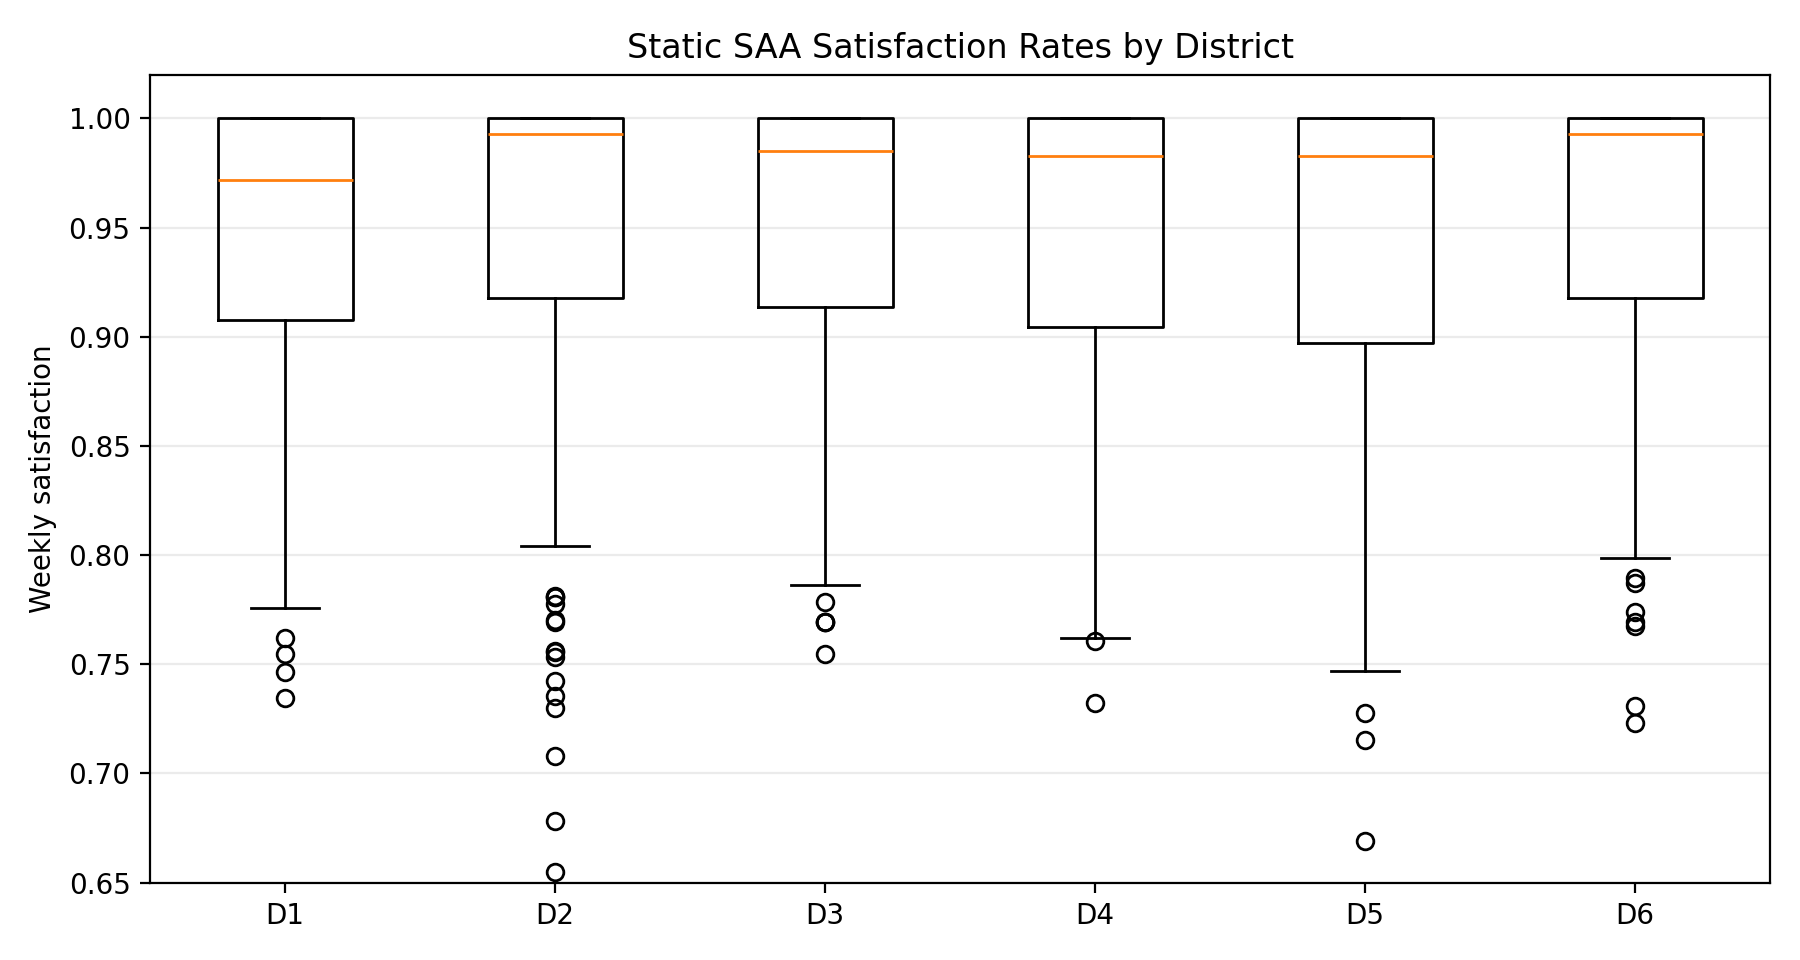


# Task 2

The dynamic policy is tuned with the same week-specific logic used at deployment time. For every candidate window width `W`, quantile level `q`, holdout year `\nu`, and target week `w \in \{10,25,43\}`, the notebook:

1. collects only the historical weeks lying in the circular neighborhood of week `w` from the other four years,
2. builds that target week's own quantile forecast `\hat\xi^{(\nu,w)}`,
3. solves the deterministic weekly planning LP on `\hat\xi^{(\nu,w)}` to obtain `(x^{(\nu,w)}, y^{(\nu,w)})`,
4. evaluates that specific plan on the holdout realization of week `w` in year `\nu`.

To avoid selecting a policy that is cheap on average but repeatedly violates the fairness target, the grid search now records both the penalized cost and the number of historical fairness violations. Candidates are ranked lexicographically: first by the number of holdout weeks with realized equity gap above `0.1`, then by penalized mean cost, and finally by the worst realized equity gap. The quantile grid is widened to `0.85` so that the search can reach a genuinely fairness-preserving regime when the data support it.

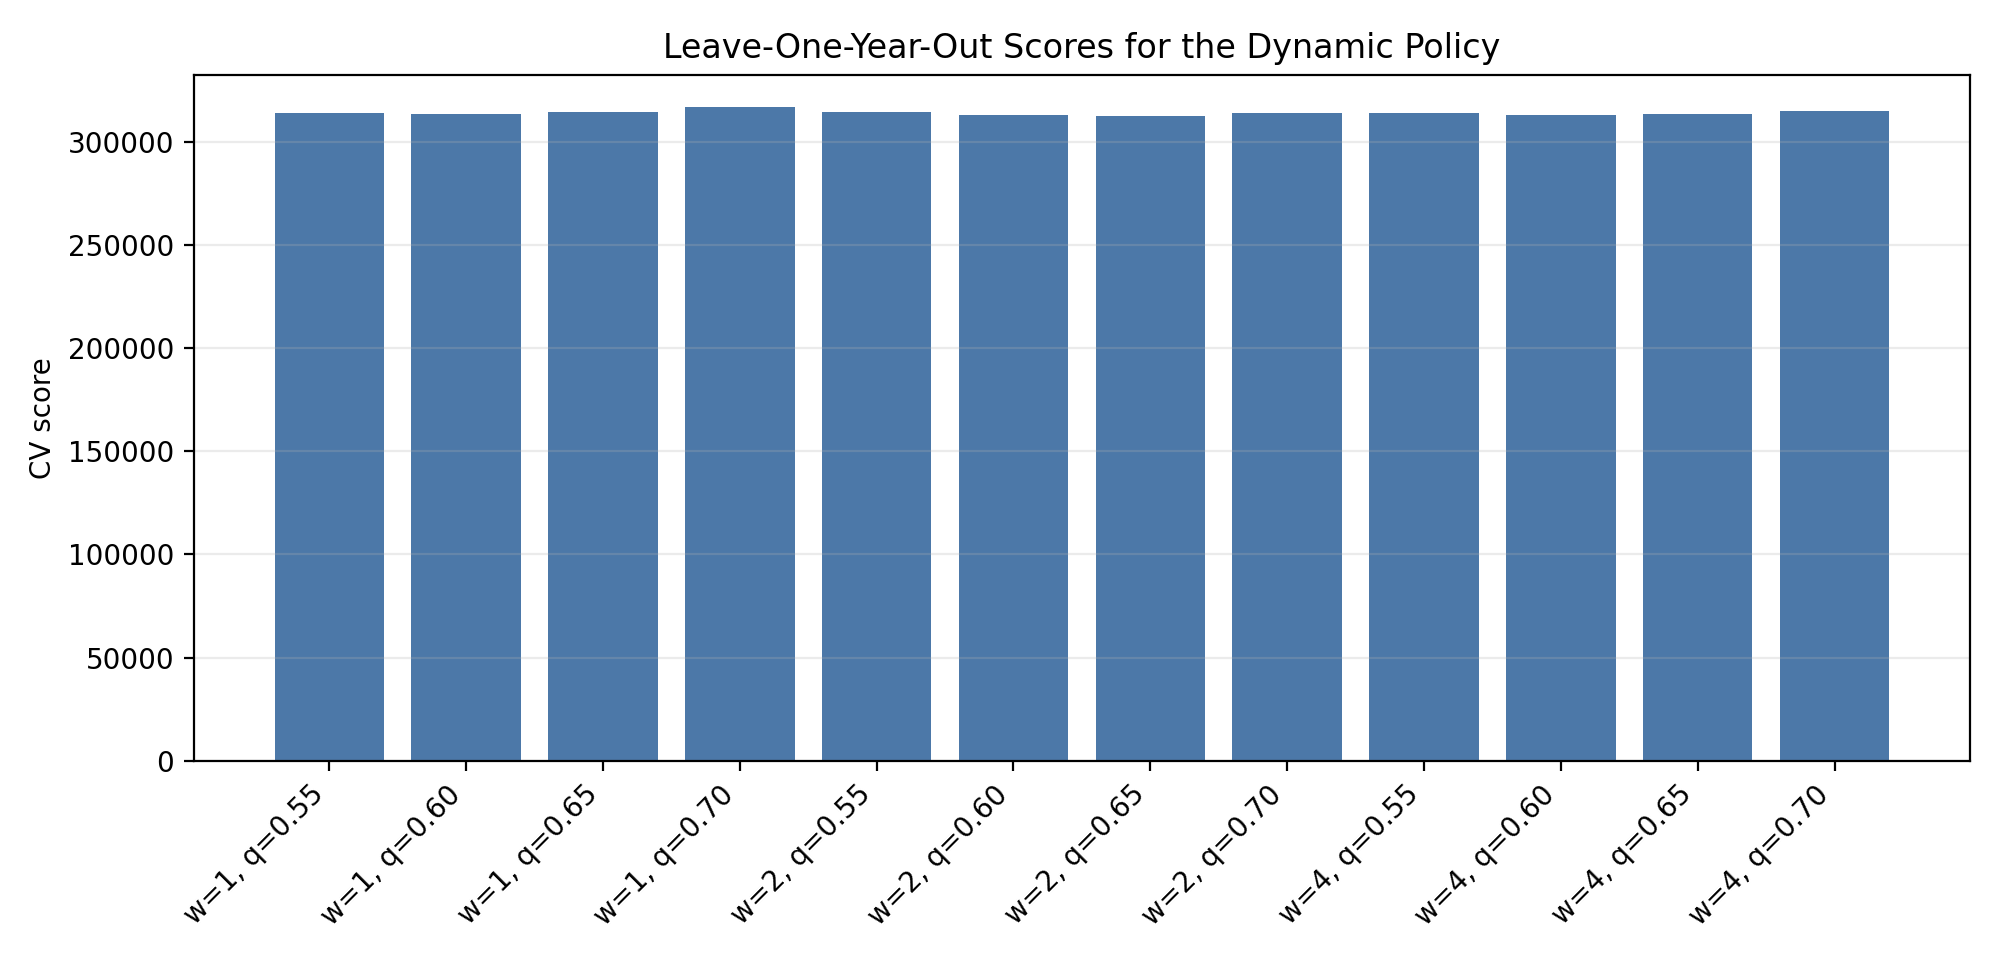

In [8]:
def Dynamic_Policy(index_of_week, Hist_Demand, ParamPolicy):
    history = normalize_demand_history(Hist_Demand)
    policy_params = None
    if isinstance(ParamPolicy, dict) and {"window", "quantile"}.issubset(ParamPolicy):
        policy_params = ParamPolicy
    results = build_dynamic_policy_results(
        history,
        target_weeks=(index_of_week,),
        policy_params=policy_params,
    )
    decision = results["decisions"][0]
    return [decision["x"], decision["new_shipments"]]


In [9]:
policy_results = build_dynamic_policy_results(Demand_by_year, target_weeks=(10, 25, 43))

print("Cross-validation grid:")
for row in policy_results["cv"]["grid"]:
    print(
        f"window={row['window']}, quantile={row['quantile']:.2f}, "
        f"violations={row['violation_count']}, score={row['score']:.2f}, "
        f"mean_fill_rate={row['mean_fill_rate']:.4f}, mean_equity_gap={row['mean_equity_gap']:.4f}, "
        f"max_equity_gap={row['max_equity_gap']:.4f}"
    )

print("\nSelected parameters:", policy_results["cv"]["best_params"])
for decision in policy_results["decisions"]:
    print(f"\nWeek {decision['week']}")
    print("x =")
    print(np.round(decision["x"], 2))
    print("y[d, i, j] by warehouse =")
    for i in range(2):
        print(f"Warehouse {i + 1}")
        print(np.round(decision["new_shipments"][:, i, :], 2))

figures = create_figures(static_result, policy_results, ARTIFACT_DIR)
summary = {"static": static_result, "dynamic": policy_results, "figures": figures}
with open(ARTIFACT_DIR / "summary.json", "w", encoding="utf-8") as handle:
    json.dump(_to_serializable(summary), handle, indent=2)


Cross-validation grid:
window=1, quantile=0.55, violations=4, score=293336.67, mean_fill_rate=0.9631, mean_equity_gap=0.0555, max_equity_gap=0.1377
window=1, quantile=0.60, violations=3, score=292980.73, mean_fill_rate=0.9679, mean_equity_gap=0.0512, max_equity_gap=0.1383
window=1, quantile=0.65, violations=1, score=293387.99, mean_fill_rate=0.9721, mean_equity_gap=0.0476, max_equity_gap=0.1425
window=1, quantile=0.70, violations=1, score=295121.24, mean_fill_rate=0.9754, mean_equity_gap=0.0428, max_equity_gap=0.1379
window=1, quantile=0.75, violations=1, score=297369.02, mean_fill_rate=0.9791, mean_equity_gap=0.0371, max_equity_gap=0.1255
window=1, quantile=0.80, violations=1, score=301233.46, mean_fill_rate=0.9825, mean_equity_gap=0.0326, max_equity_gap=0.1212
window=1, quantile=0.85, violations=1, score=306049.14, mean_fill_rate=0.9865, mean_equity_gap=0.0259, max_equity_gap=0.1097
window=2, quantile=0.55, violations=2, score=293515.31, mean_fill_rate=0.9593, mean_equity_gap=0.0580,

Dynamic-policy observations:

The revised validation loop selects `W = 4` and `q = 0.85`. This candidate records `0` historical fairness violations in the leave-one-year-out backtest, with worst realized equity gap `0.0957`. The resulting week-specific orders are `x^(10) = (7361.00, 1106.20)`, `x^(25) = (7649.20, 1144.00)`, and `x^(43) = (6263.00, 888.60)`.

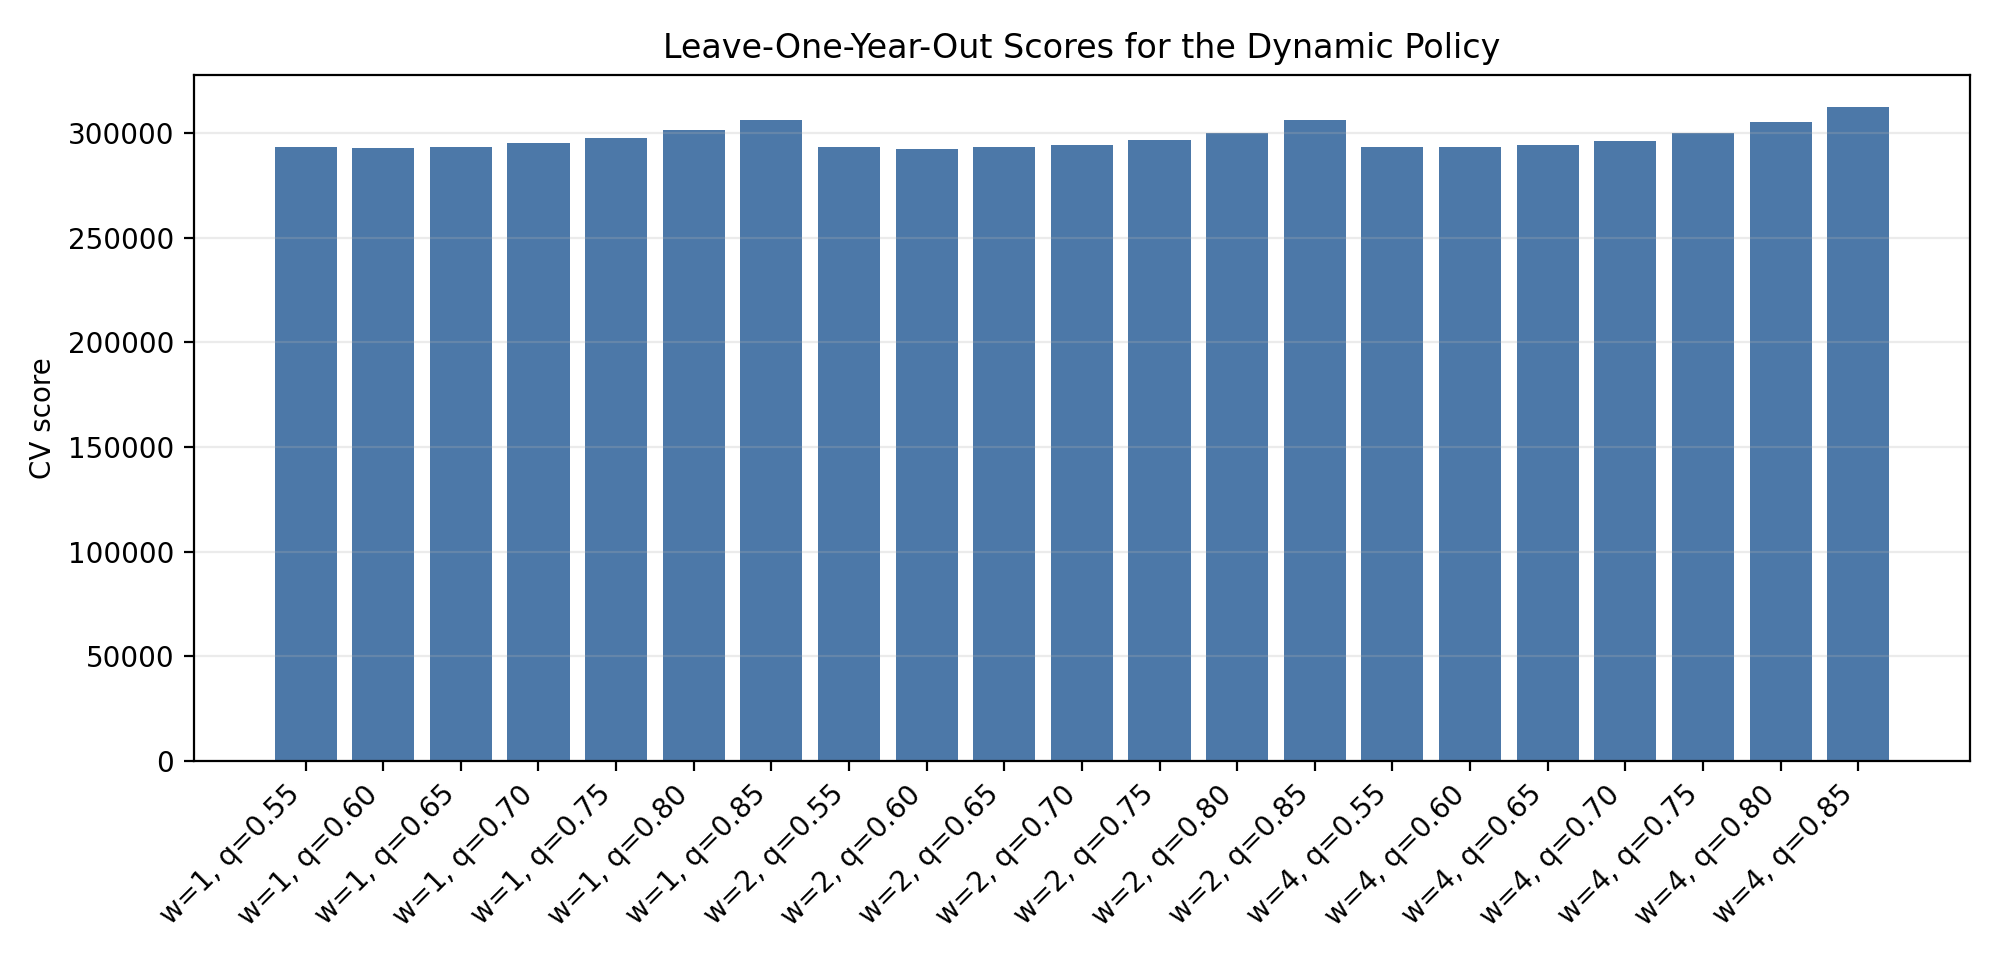

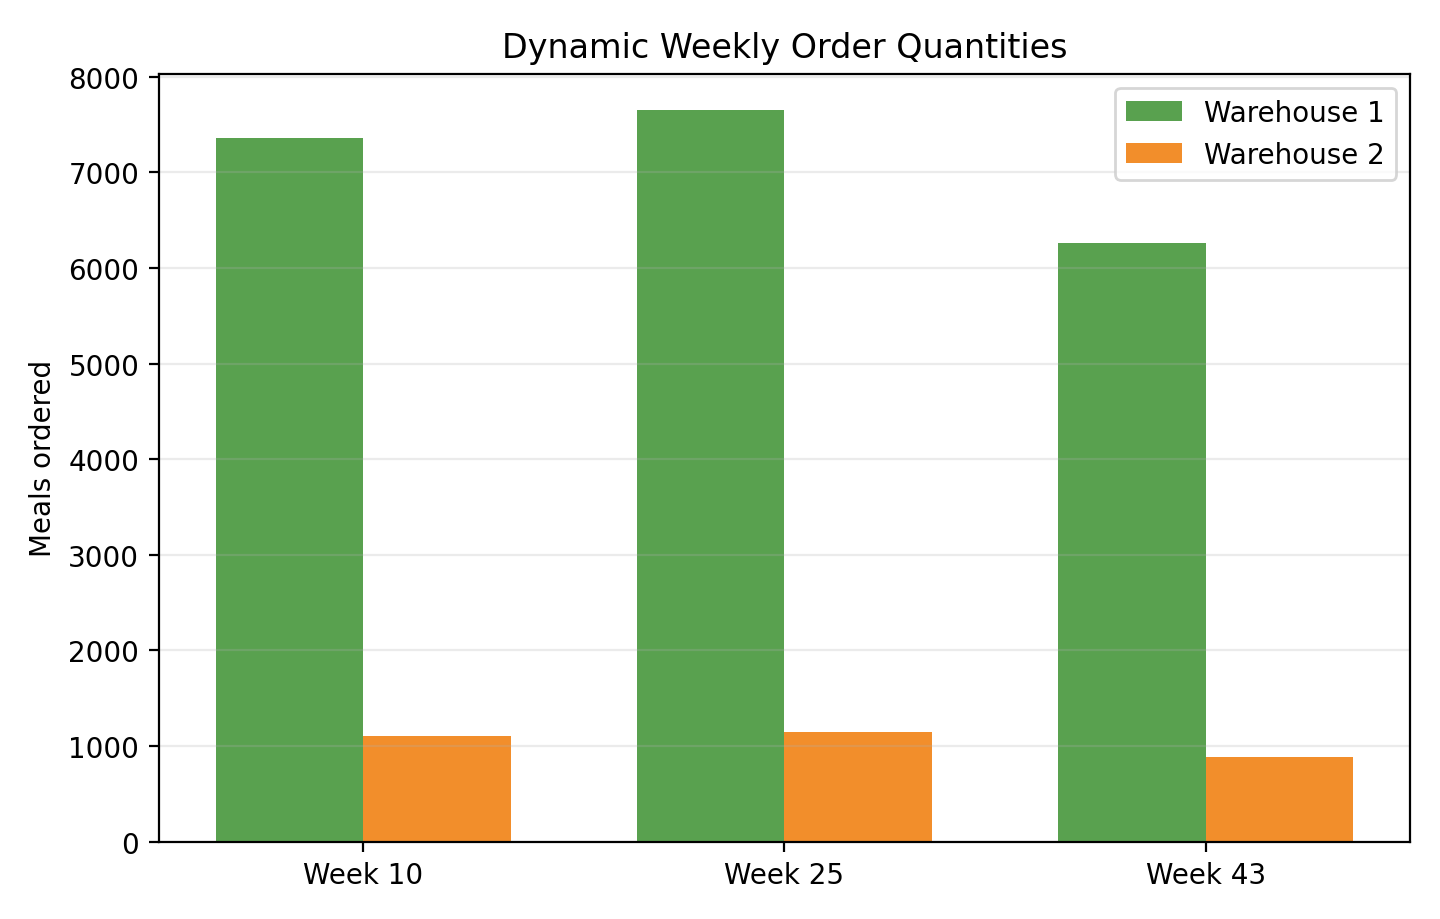


## Conclusion

Task 1 matches the PDF formulation: `x` and the full tensor `y_{d,i,j}` are common here-and-now decisions, and transportation is charged route by route through `c^t_{i,j}` rather than through a hard-coded district split. Task 2 now searches a wider quantile grid and ranks policies by historical fairness violations before penalized cost, which leads to the choice `W = 4` and `q = 0.85`.
